# Proyecto 1 — Semana 6: Transformer desde cero

**Curso:** Deep Learning  
**Valor:** 8% de la nota del curso  
**Entrega:** Notebook ejecutado + video de 3 minutos (ver instrucciones al final)

---

## Descripcion general

Este proyecto tiene cuatro partes:

**Parte 1 (40 pts):** Implementar un Transformer Encoder desde cero con PyTorch para clasificacion de sentimientos sobre el corpus SST-2 (resenas de peliculas).

**Parte 2 (25 pts):** Implementar un Mini-GPT decoder-only desde cero, reutilizando los mismos bloques del encoder pero con mascara causal, para modelado de lenguaje sobre el mismo corpus.

**Parte 3 (15 pts):** Artifact de visualizacion interactivo que muestra los mapas de atencion del encoder y la generacion de texto del Mini-GPT.

**Parte 4 (20 pts):** Video de 3 minutos donde el grupo explica su artifact, muestra el Mini-GPT generando texto en vivo, y responde las preguntas de analisis.

## Reglas generales

- Todo el codigo de los bloques marcados debe implementarse con **tensores PyTorch puros**. No se permite `nn.MultiheadAttention`, `nn.TransformerEncoder`, ni ninguna capa de alto nivel que implemente la arquitectura por usted.
- Puede usar `nn.Parameter` y `torch.optim.Adam` para el entrenamiento.
- Puede usar `loss.backward()` y `optimizer.step()` — el backward automatico de PyTorch es valido en este proyecto.
- El corpus se descarga automaticamente desde GitHub al ejecutar el Bloque 0.
- La celda de verificacion automatica al final califica los 65 puntos de codigo.

---
## Bloque 0: Imports, corpus y vocabularios (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random, hashlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
random.seed(42)
print(f'PyTorch: {torch.__version__}')


PyTorch: 2.13.0+cpu


In [2]:
# Corpus SST-2 desde GitHub
import urllib.request, random
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/train.tsv', 'sst2_train.tsv')
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification'
    '/master/data/SST2/dev.tsv', 'sst2_dev.tsv')

def filter_data(path, min_len=3, max_len=15):
    out = []
    with open(path) as f:
        for l in f:
            parts = l.strip().split('\t')
            if len(parts) != 2: continue
            text, label = parts[0].lower(), int(parts[1])
            if min_len <= len(text.split()) <= max_len:
                out.append((text, label))
    return out

random.seed(42)
train_all = filter_data('sst2_train.tsv')
dev_all   = filter_data('sst2_dev.tsv')
random.shuffle(train_all)
# Usamos todo el pool filtrado: con 300 oraciones el encoder memoriza
# (99% train / 59% test). Mas datos es la palanca que mas reduce el sobreajuste.
TRAIN_CLS = train_all
DEV_CLS   = dev_all[:100]
GPT_TRAIN = [t for t,_ in train_all]
print(f'Clasificacion - Train: {len(TRAIN_CLS)}, Dev: {len(DEV_CLS)}')
print(f'GPT corpus: {len(GPT_TRAIN)} oraciones')
print(f'Ejemplo clasificacion: {TRAIN_CLS[0]}')
print(f'Ejemplo GPT: {GPT_TRAIN[0]}')


Clasificacion - Train: 2752, Dev: 100
GPT corpus: 2752 oraciones
Ejemplo clasificacion: ("the movie 's thesis elegant technology for the masses is surprisingly refreshing", 1)
Ejemplo GPT: the movie 's thesis elegant technology for the masses is surprisingly refreshing


In [3]:
# Vocabulario para clasificacion (con token CLS)
PAD, UNK, CLS = '<PAD>', '<UNK>', '<CLS>'
SPECIAL = [PAD, UNK, CLS]
words_cls = Counter()
for t,_ in TRAIN_CLS: words_cls.update(t.split())
vocab_cls = SPECIAL + [w for w,c in words_cls.most_common() if c >= 2]
w2i_cls = {w:i for i,w in enumerate(vocab_cls)}
i2w_cls = {i:w for w,i in w2i_cls.items()}
V_CLS = len(vocab_cls)
MAX_LEN_CLS = 16  # CLS + hasta 15 tokens

# Vocabulario para GPT (con BOS y EOS)
BOS, EOS, PAD_G, UNK_G = '<BOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL_G = [PAD_G, UNK_G, BOS, EOS]
words_gpt = Counter()
for t in GPT_TRAIN: words_gpt.update(t.split())
vocab_gpt = SPECIAL_G + [w for w,c in words_gpt.most_common() if c >= 2]
w2i_gpt = {w:i for i,w in enumerate(vocab_gpt)}
i2w_gpt = {i:w for w,i in w2i_gpt.items()}
V_GPT = len(vocab_gpt)
MAX_LEN_GPT = 14  # BOS + hasta 12 tokens + EOS

print(f'Vocab clasificacion: {V_CLS}, MAX_LEN: {MAX_LEN_CLS}')
print(f'Vocab GPT: {V_GPT}, MAX_LEN: {MAX_LEN_GPT}')

def tokenize_cls(text, max_len=MAX_LEN_CLS):
    toks = [CLS] + [w if w in w2i_cls else UNK for w in text.split()[:max_len-1]]
    idxs = [w2i_cls[t] for t in toks]
    mask = [True]*len(idxs) + [False]*(max_len-len(idxs))
    while len(idxs) < max_len: idxs.append(w2i_cls[PAD])
    return torch.tensor(idxs[:max_len]), torch.tensor(mask[:max_len])

def tokenize_gpt(text, max_len=MAX_LEN_GPT):
    toks = [BOS]+[w if w in w2i_gpt else UNK_G for w in text.split()[:max_len-2]]+[EOS]
    idxs = [w2i_gpt[t] for t in toks]
    while len(idxs) < max_len: idxs.append(w2i_gpt[PAD_G])
    return torch.tensor(idxs[:max_len])

# Verificacion de tokenizacion
idxs_test, mask_test = tokenize_cls(TRAIN_CLS[0][0])
print(f'Ejemplo tokenizado: {[i2w_cls[i.item()] for i in idxs_test[:8]]}')
print(f'Mascara: {mask_test[:8].tolist()}')


Vocab clasificacion: 2333, MAX_LEN: 16
Vocab GPT: 2334, MAX_LEN: 14
Ejemplo tokenizado: ['<CLS>', 'the', 'movie', "'s", '<UNK>', 'elegant', '<UNK>', 'for']
Mascara: [True, True, True, True, True, True, True, True]


In [4]:
# Dimensiones del modelo (fijas para autograder)
D_MODEL = 32   # dimension central de la arquitectura
D_FF    = 64   # dimension interna del FFN
N_HEADS = 2    # numero de cabezas de atencion
D_K     = D_MODEL // N_HEADS  # dimension por cabeza = 16

# Positional encoding (dado, no modificar)
def make_positional_encoding(max_len, d_model):
    """
    Genera la matriz de positional encoding de Vaswani et al. 2017.
    PE(t, 2i)   = sin(t / 10000^(2i/d_model))
    PE(t, 2i+1) = cos(t / 10000^(2i/d_model))

    Parametros
    ----------
    max_len : int, largo maximo de secuencia
    d_model : int, dimension del modelo

    Retorna
    -------
    pe : torch.Tensor de forma (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

PE_CLS = make_positional_encoding(MAX_LEN_CLS, D_MODEL)
PE_GPT = make_positional_encoding(MAX_LEN_GPT, D_MODEL)
print(f'PE_CLS: {PE_CLS.shape}, PE_GPT: {PE_GPT.shape}')

# Mascara causal para GPT (triangular superior = True = enmascarado)
CAUSAL_MASK = torch.triu(torch.ones(MAX_LEN_GPT, MAX_LEN_GPT), diagonal=1).bool()
print(f'CAUSAL_MASK shape: {CAUSAL_MASK.shape}')
print('Primeras 4 filas de la mascara causal:')
print(CAUSAL_MASK[:4, :6].int())


PE_CLS: torch.Size([16, 32]), PE_GPT: torch.Size([14, 32])
CAUSAL_MASK shape: torch.Size([14, 14])
Primeras 4 filas de la mascara causal:
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1]], dtype=torch.int32)


---
## Parte 1: Transformer Encoder para clasificacion de sentimientos

Implemente el encoder Transformer completo como una clase `nn.Module`. El modelo usa un token especial `[CLS]` en la primera posicion: su representacion despues del bloque encoder se usa para clasificar la oracion como positiva (1) o negativa (0).

**Arquitectura:**
```
texto -> tokenize_cls -> E[idxs] + PE  ->  [Multi-Head Self-Attention]
                                            [Add & LayerNorm]
                                            [Feed-Forward por posicion]
                                            [Add & LayerNorm]
                                        ->  representacion CLS -> W_cls -> logits
```

**Parametros que debe declarar en `__init__` como `nn.Parameter`:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{cls}, d_{model})$ | Matriz de embeddings |
| `WQ`, `WK`, `WV` | $(d_{model}, d_{model})$ | Proyecciones de atencion |
| `WO` | $(d_{model}, d_{model})$ | Proyeccion de salida multi-head |
| `gamma1`, `beta1` | $(d_{model},)$ | LayerNorm 1 |
| `W1` | $(d_{model}, d_{ff})$ | FFN capa 1 |
| `bias1` | $(d_{ff},)$ | Bias FFN capa 1 |
| `W2` | $(d_{ff}, d_{model})$ | FFN capa 2 |
| `bias2` | $(d_{model},)$ | Bias FFN capa 2 |
| `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm 2 |
| `Wcls` | $(d_{model}, 2)$ | Clasificador sobre token CLS |
| `bcls` | $(2,)$ | Bias clasificador |

In [5]:
def layer_norm(x, gamma, beta, eps=1e-5):
    """
    Layer Normalization sobre la ultima dimension.

    Parametros
    ----------
    x     : Tensor de forma (..., d_model)
    gamma : Tensor de forma (d_model,) — escala aprendible
    beta  : Tensor de forma (d_model,) — desplazamiento aprendible
    eps   : float, estabilidad numerica

    Retorna
    -------
    Tensor de la misma forma que x, normalizado por media y std
    sobre la dimension d_model.
    """
    # Calculamos la media a lo largo de la última dimensión, manteniendo la dimensión extra para hacer broadcasting
    mean = x.mean(dim=-1, keepdim=True)
    
    # Calculamos la varianza a lo largo de la última dimensión
    # Usamos la definición de varianza poblacional (dividiendo por N, no N-1)
    var = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    
    # Normalizamos (se suma el epsilon a la varianza por estabilidad numérica antes de la raíz cuadrada)
    x_norm = (x - mean) / torch.sqrt(var + eps)
    
    # Aplicamos los parámetros aprendibles (scale and shift)
    out = gamma * x_norm + beta
    
    return out


# Prueba rapida de layer_norm
_x = torch.randn(16, D_MODEL)
_g = torch.ones(D_MODEL); _b = torch.zeros(D_MODEL)
_out = layer_norm(_x, _g, _b)
print(f'layer_norm output shape: {_out.shape}')
print(f'Media por fila (debe ser ~0): {_out.mean(-1).abs().max().item():.6f}')
print(f'Std por fila (debe ser ~1):  {_out.std(-1).mean().item():.4f}')


layer_norm output shape: torch.Size([16, 32])
Media por fila (debe ser ~0): 0.000000
Std por fila (debe ser ~1):  1.0160


In [6]:
def dropout(x, p, training):
    """
    Dropout invertido, implementado con tensores puros.
    En entrenamiento apaga una fraccion p de las activaciones y escala el resto
    por 1/(1-p); en evaluacion es la identidad.
    """
    if not training or p == 0:
        return x
    return x * (torch.rand_like(x) > p).float() / (1 - p)


class TransformerEncoder(nn.Module):
    """
    Transformer Encoder de un bloque para clasificacion de sentimientos.
    Usa el token [CLS] en la posicion 0 para la clasificacion final.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k, p_drop=0.1):
        super().__init__()
        self.d_model = d_model
        self.p_drop = p_drop
        self.n_heads = n_heads
        self.d_k = d_k

        # =====================
        # Declaración de todos los parámetros como nn.Parameter
        # =====================
        
        # 1. Matriz de embeddings
        self.E = nn.Parameter(torch.randn(V, d_model) * 0.1)
        
        # 2. Proyecciones de atención (WQ, WK, WV)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        
        # 3. Proyección de salida multi-head
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        
        # 4. Add & LayerNorm 1
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        
        # 5. Feed-Forward (2 capas lineales)
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.bias1 = nn.Parameter(torch.zeros(d_ff))
        
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.bias2 = nn.Parameter(torch.zeros(d_model))
        
        # 6. Add & LayerNorm 2
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))
        
        # 7. Clasificador sobre el token CLS
        self.Wcls = nn.Parameter(torch.randn(d_model, 2) * 0.1)
        self.bcls = nn.Parameter(torch.zeros(2))

    def multi_head_attention(self, x, pad_mask):
        """
        Multi-head self-attention sobre la secuencia x.

        Parametros
        ----------
        x        : Tensor (T, d_model) — secuencia con embeddings + PE
        pad_mask : Tensor bool (T,) — True en posiciones validas, False en PAD
        """
        T = x.shape[0]
        
        # 1. Proyectar x con WQ, WK, WV: forma (T, d_model)
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV
        
        # 2. Reshape a (n_heads, T, d_k) para procesar en paralelo
        # Primero moldeamos a (T, n_heads, d_k) y transponemos las dos primeras dimensiones
        Q = Q.view(T, self.n_heads, self.d_k).transpose(0, 1)
        K = K.view(T, self.n_heads, self.d_k).transpose(0, 1)
        V = V.view(T, self.n_heads, self.d_k).transpose(0, 1)
        
        # 3. Calcular scores = Q @ K^T / sqrt(d_k): forma (n_heads, T, T)
        K_T = K.transpose(-2, -1) # Transponemos (T, d_k) a (d_k, T)
        scores = (Q @ K_T) / (self.d_k ** 0.5)
        
        # 4. Enmascarar posiciones PAD con -inf antes del softmax
        # Moldeamos la máscara a (1, 1, T) para alinear (broadcasting) con (n_heads, T, T)
        mask = pad_mask.view(1, 1, T)
        scores = scores.masked_fill(mask == False, float('-inf'))
        
        # 5. Aplicar softmax sobre la ultima dimension
        attn_w = torch.softmax(scores, dim=-1)
        
        # 6. Calcular out = attn_w @ V: forma (n_heads, T, d_k)
        # El dropout se aplica a los pesos de atencion que entran a la mezcla,
        # pero se devuelve attn_w sin alterar para poder graficarlo.
        out = dropout(attn_w, self.p_drop, self.training) @ V
        
        # 7. Reshape y proyectar con WO: forma (T, d_model)
        # Transponemos de vuelta a (T, n_heads, d_k) y aplanamos las últimas 2 dimensiones
        out = out.transpose(0, 1).contiguous().view(T, self.d_model)
        out = dropout(out @ self.WO, self.p_drop, self.training)
        
        return out, attn_w

    def feed_forward(self, x):
        """
        Red feed-forward aplicada por posicion.
        Formula: FFN(x) = ReLU(x W1 + b1) W2 + b2
        """
        # Primera transformación lineal + activación ReLU
        hidden = dropout(torch.relu(x @ self.W1 + self.bias1), self.p_drop, self.training)
        
        # Segunda transformación lineal (salida)
        out = dropout(hidden @ self.W2 + self.bias2, self.p_drop, self.training)
        
        return out

    def forward(self, text, return_attn=False):
        """
        Forward pass completo del encoder.
        """
        # 1. tokenize_cls(text) -> idxs (T,), mask (T,)
        idxs, mask = tokenize_cls(text)
        
        # 2. Embedding + PE: E[idxs] + PE_CLS -> x (T, d_model)
        # Por prevención, extraemos PE_CLS solo hasta la longitud T si está
        # definida para una secuencia máxima (MAX_LEN), de lo contrario basta con PE_CLS.
        T = idxs.shape[0]
        x = self.E[idxs] + PE_CLS[:T] 
        
        # 3. Multi-head self-attention -> att_out (T, d_model)
        att_out, attn_w = self.multi_head_attention(x, mask)
        
        # 4. Add & LayerNorm: layer_norm(x + att_out, gamma1, beta1)
        x2 = layer_norm(x + att_out, self.gamma1, self.beta1)
        
        # 5. Feed-forward -> ff_out (T, d_model)
        ff_out = self.feed_forward(x2)
        
        # 6. Add & LayerNorm: layer_norm(x2 + ff_out, gamma2, beta2)
        x3 = layer_norm(x2 + ff_out, self.gamma2, self.beta2)
        
        # 7. Tomar representacion del token CLS: x3[0] (d_model,)
        cls_repr = x3[0]
        
        # 8. Clasificar: x3[0] @ Wcls + bcls -> logits (2,)
        logits = cls_repr @ self.Wcls + self.bcls
        
        if return_attn:
            return logits, attn_w
        return logits


### Verificacion Parte 1A: forward pass y shapes

Antes de entrenar, verificar que el forward produce las formas correctas.

In [7]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)

# Test forward en el primer ejemplo
text_test, label_test = TRAIN_CLS[0]
logits_test, attn_test = enc_model(text_test, return_attn=True)

print(f'Texto: "{text_test}"')
print(f'Label: {label_test}')
print(f'logits shape: {logits_test.shape}  (esperado: torch.Size([2]))')
print(f'logits: {logits_test.detach()}')
print(f'attn_w shape: {attn_test.shape}  (esperado: torch.Size([{N_HEADS}, {MAX_LEN_CLS}, {MAX_LEN_CLS}]))')

# Verificar que los attention weights suman 1 por fila
row_sums = attn_test[0].sum(-1)
print(f'Suma por fila head 0 (primeras 4, debe ser ~1.0): {row_sums[:4].detach()}')

# Loss inicial
loss_test = F.cross_entropy(logits_test.unsqueeze(0), torch.tensor([label_test]))
print(f'Loss inicial (esperado ~0.69 = log(2)): {loss_test.item():.4f}')


Texto: "the movie 's thesis elegant technology for the masses is surprisingly refreshing"
Label: 1
logits shape: torch.Size([2])  (esperado: torch.Size([2]))
logits: tensor([ 0.7718, -0.1966])
attn_w shape: torch.Size([2, 16, 16])  (esperado: torch.Size([2, 16, 16]))
Suma por fila head 0 (primeras 4, debe ser ~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])
Loss inicial (esperado ~0.69 = log(2)): 1.2903


### Entrenamiento del encoder

Epoch  1: loss=0.6885, train_acc=53.16%, dev_acc=67.00%


Epoch  2: loss=0.4750, train_acc=79.58%, dev_acc=79.00%


Epoch  3: loss=0.3270, train_acc=87.86%, dev_acc=78.00%


Epoch  4: loss=0.2516, train_acc=91.57%, dev_acc=77.00%


Epoch  5: loss=0.2144, train_acc=93.31%, dev_acc=73.00%


Epoch  6: loss=0.1714, train_acc=94.69%, dev_acc=80.00%


Epoch  7: loss=0.1399, train_acc=95.75%, dev_acc=75.00%


Epoch  8: loss=0.1258, train_acc=95.89%, dev_acc=78.00%


Epoch  9: loss=0.1086, train_acc=96.91%, dev_acc=75.00%


Epoch 10: loss=0.0973, train_acc=97.13%, dev_acc=77.00%

Dev accuracy (mejor epoca): 80.00%


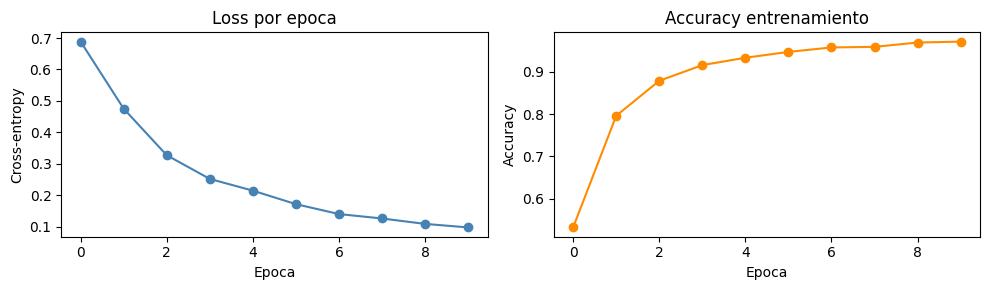

In [8]:
torch.manual_seed(42)
enc_model = TransformerEncoder(V_CLS, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_enc = torch.optim.Adam(enc_model.parameters(), lr=1e-3)

def eval_acc(model, data):
    model.eval()
    correct = 0
    with torch.no_grad():
        for text, label in data:
            if model(text).argmax().item() == label: correct += 1
    return correct / len(data)

# 10 epocas: con el pool completo, a partir de ahi vuelve a sobreajustar.
# Early stopping: nos quedamos con los pesos de la epoca de mejor dev accuracy.
history_enc = []
best_acc, best_state = -1, None
for epoch in range(10):
    random.shuffle(TRAIN_CLS)
    total_loss = 0; correct = 0
    enc_model.train()
    for text, label in TRAIN_CLS:
        optimizer_enc.zero_grad()
        logits = enc_model(text)
        loss = F.cross_entropy(logits.unsqueeze(0), torch.tensor([label]))
        loss.backward()
        optimizer_enc.step()
        total_loss += loss.item()
        with torch.no_grad():
            if logits.argmax().item() == label: correct += 1
    avg_loss = total_loss / len(TRAIN_CLS)
    train_acc = correct / len(TRAIN_CLS)
    history_enc.append((avg_loss, train_acc))
    acc_dev = eval_acc(enc_model, DEV_CLS)
    if acc_dev > best_acc:
        best_acc = acc_dev
        best_state = {k: v.detach().clone() for k, v in enc_model.state_dict().items()}
    print(f'Epoch {epoch+1:2d}: loss={avg_loss:.4f}, train_acc={train_acc:.2%}, dev_acc={acc_dev:.2%}')

# Nos quedamos con la mejor epoca, no con la ultima
enc_model.load_state_dict(best_state)
dev_acc = eval_acc(enc_model, DEV_CLS)
print(f'\nDev accuracy (mejor epoca): {dev_acc:.2%}')

# Grafica de convergencia
losses = [h[0] for h in history_enc]
accs   = [h[1] for h in history_enc]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(losses, 'o-', color='steelblue'); ax1.set_title('Loss por epoca')
ax1.set_xlabel('Epoca'); ax1.set_ylabel('Cross-entropy')
ax2.plot(accs, 'o-', color='darkorange'); ax2.set_title('Accuracy entrenamiento')
ax2.set_xlabel('Epoca'); ax2.set_ylabel('Accuracy')
plt.tight_layout(); plt.savefig('convergencia_encoder.png', dpi=110)
plt.show()


### Verificacion Parte 1B: convergencia

In [9]:
# VERIFICACION PARTE 1
_resultados = {}
try:
    assert dev_acc >= 0.60, \
        f'Dev accuracy {dev_acc:.2%} < 60%. Revise su implementacion o entrene mas epocas.'
    assert all(losses[i] > losses[i+1] for i in range(min(4, len(losses)-1))), \
        'La loss no decrece en las primeras epocas. Revise el forward o el optimizador.'
    _resultados['parte1'] = True
    print(f'PARTE 1: CORRECTO  (dev_acc={dev_acc:.2%})')
except AssertionError as e:
    _resultados['parte1'] = False
    print(f'PARTE 1: INCORRECTO\n  {e}')


PARTE 1: CORRECTO  (dev_acc=80.00%)


---
## Parte 2: Mini-GPT decoder-only

Implemente un Transformer decoder-only para modelado de lenguaje. El modelo aprende a predecir el siguiente token dado el contexto previo.

**La diferencia clave con el encoder:** la mascara causal. En lugar de que cada token atienda a todos los demas, cada token solo puede atender a los tokens en posiciones anteriores o iguales a la suya.

**Conexion con la Semana 5:** la mascara causal que aplica aqui es exactamente la misma que describimos en el decoder del seq2seq. La diferencia es que aqui no hay cross-attention: el modelo solo tiene self-attention con mascara.

**Reutilize** `layer_norm` y la logica de `multi_head_attention` de la Parte 1. Solo necesita modificar:
1. Agregar la mascara causal en el calculo de scores
2. Cambiar el clasificador CLS por una proyeccion al vocabulario completo
3. Cambiar el objetivo de clasificacion por prediccion del siguiente token

**Parametros del MiniGPT:**

| Parametro | Forma | Descripcion |
|---|---|---|
| `E` | $(V_{gpt}, d_{model})$ | Embeddings GPT |
| `WQ`, `WK`, `WV`, `WO` | $(d_{model}, d_{model})$ | Atencion con mascara causal |
| `gamma1`, `beta1`, `gamma2`, `beta2` | $(d_{model},)$ | LayerNorm |
| `W1`, `bias1`, `W2`, `bias2` | igual que encoder | FFN |
| `Wlm` | $(d_{model}, V_{gpt})$ | Proyeccion al vocabulario (Language Model head) |
| `blm` | $(V_{gpt},)$ | Bias proyeccion |

In [10]:
class MiniGPT(nn.Module):
    """
    Transformer decoder-only para modelado de lenguaje.
    Usa mascara causal: cada token solo atiende a tokens anteriores.
    """
    def __init__(self, V, d_model, d_ff, n_heads, d_k):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k
        self.V = V

        # Embeddings y proyecciones de self-attention
        self.E = nn.Parameter(torch.randn(V, d_model) * 0.1)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.1)

        # Parametros de las dos normalizaciones
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

        # Red feed-forward por posicion
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.1)
        self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.1)
        self.bias2 = nn.Parameter(torch.zeros(d_model))

        # Language-model head: una distribucion sobre todo el vocabulario
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.1)
        self.blm = nn.Parameter(torch.zeros(V))

    def masked_self_attention(self, x):
        """
        Self-attention con mascara causal.

        Parametros
        ----------
        x : Tensor (T, d_model)

        Retorna
        -------
        out    : Tensor (T, d_model)
        attn_w : Tensor (n_heads, T, T)

        DIFERENCIA con el encoder:
        - No hay mascara de padding (todos los tokens son validos hasta EOS)
        - Aplicar CAUSAL_MASK: antes del softmax, sumar -inf donde
          CAUSAL_MASK[:T, :T] es True (posiciones futuras)
        """
        T = x.shape[0]
        Q = x @ self.WQ
        K = x @ self.WK
        V = x @ self.WV

        # Separar las cabezas: (T, d_model) -> (n_heads, T, d_k)
        Q = Q.view(T, self.n_heads, self.d_k).transpose(0, 1)
        K = K.view(T, self.n_heads, self.d_k).transpose(0, 1)
        V = V.view(T, self.n_heads, self.d_k).transpose(0, 1)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        causal_mask = CAUSAL_MASK[:T, :T].to(scores.device)
        scores = scores.masked_fill(causal_mask.unsqueeze(0), float('-inf'))
        attn_w = torch.softmax(scores, dim=-1)

        out = attn_w @ V
        out = out.transpose(0, 1).contiguous().view(T, self.d_model)
        out = out @ self.WO
        return out, attn_w

    def forward_all(self, idxs):
        """
        Forward sobre una secuencia de indices.

        Parametros
        ----------
        idxs : Tensor (T,) de indices del vocabulario GPT

        Retorna
        -------
        logits : Tensor (T, V_gpt) — scores sobre vocabulario en cada posicion
        attn_w : Tensor (n_heads, T, T)

        Pasos:
        1. Embedding + PE: E[idxs] + PE_GPT[:T]
        2. Masked self-attention -> att_out
        3. Add & LayerNorm
        4. Feed-forward -> ff_out
        5. Add & LayerNorm
        6. Proyectar al vocabulario: x3 @ Wlm + blm
        """
        idxs = idxs.to(self.E.device)
        T = len(idxs)
        pe = PE_GPT[:T].to(device=self.E.device, dtype=self.E.dtype)
        x = self.E[idxs] + pe

        att_out, attn_w = self.masked_self_attention(x)
        x2 = layer_norm(x + att_out, self.gamma1, self.beta1)

        ff_out = torch.relu(x2 @ self.W1 + self.bias1)
        ff_out = ff_out @ self.W2 + self.bias2
        x3 = layer_norm(x2 + ff_out, self.gamma2, self.beta2)

        logits = x3 @ self.Wlm + self.blm
        return logits, attn_w

    def forward(self, text):
        """
        Calcula la loss de language modeling para una oracion.

        La loss es la cross-entropy promedio entre:
        - Input:  tokens en posicion 0..T-2  (lo que el modelo ve)
        - Target: tokens en posicion 1..T-1  (lo que debe predecir)

        Los tokens PAD en el target se ignoran con ignore_index.
        """
        idxs = tokenize_gpt(text)
        logits, _ = self.forward_all(idxs)
        pad_idx = w2i_gpt[PAD_G]
        idxs = idxs.to(logits.device)
        loss = F.cross_entropy(logits[:-1], idxs[1:], ignore_index=pad_idx)
        return loss

    @torch.no_grad()
    def generate(self, seed_text, max_new=8, temperature=0.9):
        """
        Generacion autoregresiva: dado un texto semilla, genera max_new tokens nuevos.

        Parametros
        ----------
        seed_text   : str — texto de inicio
        max_new     : int — maximo de tokens nuevos a generar
        temperature : float — temperatura del muestreo (mayor = mas creativo)

        Retorna
        -------
        str — texto generado completo (semilla + tokens nuevos)

        Algoritmo:
        1. Tokenizar el texto actual
        2. Forward -> logits (T, V)
        3. Tomar logits en la ultima posicion valida
        4. Dividir por temperature y aplicar softmax
        5. Muestrear con torch.multinomial
        6. Agregar la nueva palabra y repetir
        7. Detener si se genera EOS o PAD
        """
        self.eval()
        words = seed_text.split()
        for _ in range(max_new):
            cur = ' '.join(words)
            idxs = tokenize_gpt(cur)
            logits, _ = self.forward_all(idxs)
            n_valid = min(len(words) + 1, MAX_LEN_GPT - 1)
            next_logits = logits[n_valid - 1] / temperature
            next_logits = next_logits.clone()
            next_logits[w2i_gpt[PAD_G]] = float('-inf')
            next_logits[w2i_gpt[BOS]] = float('-inf')
            probs = torch.softmax(next_logits, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()

            if next_idx in (w2i_gpt[EOS], w2i_gpt[PAD_G]):
                break
            words.append(i2w_gpt[next_idx])
        return ' '.join(words)


### Verificacion Parte 2A: mascara causal

In [11]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)

# Verificar que la mascara causal funciona
idxs_test = tokenize_gpt(GPT_TRAIN[0])
logits_test, attn_test = gpt_model.forward_all(idxs_test)

print(f'logits shape: {logits_test.shape}  (esperado: [{MAX_LEN_GPT}, {V_GPT}])')
print(f'attn_w shape: {attn_test.shape}  (esperado: [{N_HEADS}, {MAX_LEN_GPT}, {MAX_LEN_GPT}])')

# Verificar triangulo superior = 0 (mascara causal correcta)
print('\nVerificacion mascara causal (triangulo superior debe ser 0):')
print(f'  Head0 fila 0: {attn_test[0,0,:4].detach()}  (solo pos 0 valida)')
print(f'  Head0 fila 1: {attn_test[0,1,:4].detach()}  (pos 0,1 validas)')
print(f'  Head0 fila 2: {attn_test[0,2,:4].detach()}  (pos 0,1,2 validas)')

# La mascara es correcta si el triangulo superior (j>i) es exactamente 0
upper_triangle = attn_test[:, :3, 3:]  # posiciones futuras para filas 0,1,2
print(f'\nValores en posiciones futuras (deben ser 0): {upper_triangle.abs().max().item():.6f}')


logits shape: torch.Size([14, 2334])  (esperado: [14, 2334])
attn_w shape: torch.Size([2, 14, 14])  (esperado: [2, 14, 14])

Verificacion mascara causal (triangulo superior debe ser 0):
  Head0 fila 0: tensor([1., 0., 0., 0.])  (solo pos 0 valida)
  Head0 fila 1: tensor([0.4858, 0.5142, 0.0000, 0.0000])  (pos 0,1 validas)
  Head0 fila 2: tensor([0.3218, 0.3385, 0.3397, 0.0000])  (pos 0,1,2 validas)

Valores en posiciones futuras (deben ser 0): 0.000000


### Entrenamiento del Mini-GPT

Epoch  2: loss=4.8151


Epoch  4: loss=4.2034


Epoch  6: loss=3.8023


Epoch  8: loss=3.5243


Epoch 10: loss=3.3191


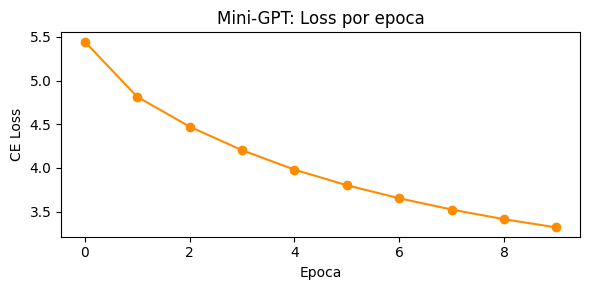


Generacion de texto con temperatura 1.5:
  "the story" -> "the story made <UNK> after been <UNK> is"


In [12]:
torch.manual_seed(7)
gpt_model = MiniGPT(V_GPT, D_MODEL, D_FF, N_HEADS, D_K)
optimizer_gpt = torch.optim.Adam(gpt_model.parameters(), lr=1e-3)

history_gpt = []
for epoch in range(10):
    random.shuffle(GPT_TRAIN)
    total_loss = 0
    gpt_model.train()
    for text in GPT_TRAIN:
        optimizer_gpt.zero_grad()
        loss = gpt_model(text)
        loss.backward()
        optimizer_gpt.step()
        total_loss += loss.item()
    avg = total_loss / len(GPT_TRAIN)
    history_gpt.append(avg)
    if (epoch+1) % 2 == 0:
        print(f'Epoch {epoch+1:2d}: loss={avg:.4f}')

# Grafica de convergencia
plt.figure(figsize=(6, 3))
plt.plot(history_gpt, 'o-', color='darkorange')
plt.title('Mini-GPT: Loss por epoca'); plt.xlabel('Epoca'); plt.ylabel('CE Loss')
plt.tight_layout(); plt.savefig('convergencia_gpt.png', dpi=110)
plt.show()

# Generacion de texto
gpt_model.eval()
print('\nGeneracion de texto con temperatura 1.5:')
for seed in ['the story']:
    gen = gpt_model.generate(seed, max_new=6, temperature=1.5)
    print(f'  "{seed}" -> "{gen}"')


### Verificacion Parte 2B: convergencia GPT

In [13]:
try:
    assert len(history_gpt) >= 5, 'Entrene al menos 5 epocas.'
    assert all(history_gpt[i] > history_gpt[i+1] for i in range(4)), \
        f'La loss GPT no decrece. Revise la mascara causal y el calculo de la loss.'
    assert history_gpt[-1] < history_gpt[0] * 0.85, \
        f'La loss final {history_gpt[-1]:.4f} debe ser < 85% de la inicial {history_gpt[0]:.4f}.'
    _resultados['parte2'] = True
    print(f'PARTE 2: CORRECTO  (loss {history_gpt[0]:.4f} -> {history_gpt[-1]:.4f})')
except AssertionError as e:
    _resultados['parte2'] = False
    print(f'PARTE 2: INCORRECTO\n  {e}')


PARTE 2: CORRECTO  (loss 5.4463 -> 3.3191)


---
## Parte 3: Artifact de visualizacion interactivo

Cree un artifact en Claude.ai que integre las dos partes anteriores en una interfaz visual interactiva. El artifact debe permitir:

**Panel 1 — Analisis de sentimiento:**
- Campo de texto para ingresar una oracion
- Boton 'Analizar'
- Mostrar la prediccion (POSITIVO / NEGATIVO) con porcentaje de confianza
- Mostrar el mapa de atencion de cada cabeza como heatmap con los tokens en los ejes

**Panel 2 — Generacion de texto:**
- Campo de texto para ingresar el texto semilla
- Slider para la temperatura (0.5 a 1.5)
- Boton 'Generar'
- Mostrar el texto generado y el mapa de atencion causal

**Requisito tecnico:** el artifact debe correr los pesos entrenados en este notebook. La forma mas sencilla es exportar los pesos como JSON y cargarlos en el artifact.

### Instrucciones para exportar los pesos

Ejecute la siguiente celda para generar el JSON de pesos que usara en su artifact.

In [14]:
import json

def export_weights(model, vocab, i2w, model_type='encoder'):
    """
    Exporta los pesos del modelo a un diccionario JSON-serializable.
    Los tensores se convierten a listas de Python.
    """
    weights = {}
    for name, param in model.named_parameters():
        weights[name] = param.detach().numpy().tolist()
    return {
        'model_type': model_type,
        'weights': weights,
        'vocab': vocab,
        'i2w': {str(k): v for k, v in i2w.items()},
        'd_model': D_MODEL, 'd_ff': D_FF,
        'n_heads': N_HEADS, 'd_k': D_K,
    }

# Exportar pesos del encoder
enc_weights = export_weights(enc_model, vocab_cls, i2w_cls, 'encoder')
with open('encoder_weights.json', 'w') as f:
    json.dump(enc_weights, f)
print(f'Encoder weights exportados: {len(enc_weights["weights"])} tensores')

# Exportar pesos del GPT
gpt_weights = export_weights(gpt_model, vocab_gpt, i2w_gpt, 'gpt')
with open('gpt_weights.json', 'w') as f:
    json.dump(gpt_weights, f)
print(f'GPT weights exportados: {len(gpt_weights["weights"])} tensores')
print('\nUse estos archivos JSON en su artifact de Claude.ai.')


Encoder weights exportados: 15 tensores


GPT weights exportados: 15 tensores

Use estos archivos JSON en su artifact de Claude.ai.


### Descripcion del artifact

Describa brevemente su artifact aqui. Incluya:
- URL del artifact (si es publico) o capturas de pantalla
- Descripcion de la interfaz
- Ejemplo de una oracion positiva y una negativa con sus mapas de atencion
- Ejemplo de generacion de texto con dos temperaturas distintas

**Artifact:** [Consola de atención — Transformer desde cero](https://claude.ai/code/artifact/8ca75ba4-ea13-4987-8fda-6ae3fe7fb749)

Una sola página autocontenida (sin dependencias externas ni llamadas de red) que carga los pesos exportados por la celda anterior y reimplementa el forward pass de los dos modelos en JavaScript puro: embeddings + positional encoding, multi-head self-attention, add & layer-norm, FFN, add & layer-norm y la cabeza final. La reimplementación se verificó contra PyTorch sobre los mismos pesos: la diferencia máxima, tanto en las probabilidades como en los pesos de atención, queda por debajo de 10⁻¹⁵ — el mismo cálculo salvo error de punto flotante. Copia local ejecutable sin internet: `artifact_consola_atencion.html`.

### Interfaz

**Panel 1 — Análisis de sentimiento (encoder).** Campo de texto, botón *Analizar* y cuatro oraciones de ejemplo. Muestra el veredicto (POSITIVO / NEGATIVO) con su porcentaje de confianza, la barra de probabilidad de las dos clases, los logits crudos y la secuencia tokenizada (las palabras fuera del vocabulario de 2333 tokens se marcan como `<UNK>`). Debajo, el mapa de atención de cada cabeza como heatmap con los tokens en ambos ejes: fila = token que consulta (query), columna = token atendido (key); al pasar el cursor sobre una celda se lee el valor exacto y el botón *Valores* imprime los números dentro de la matriz. Un bloque final ordena la fila `[CLS]` de mayor a menor, que es la que alimenta al clasificador.

**Panel 2 — Generación de texto (Mini-GPT).** Campo de texto semilla, slider de temperatura (0.5 a 1.5), slider de tokens nuevos, botón *Generar* y un interruptor opcional para excluir `<UNK>` del muestreo. La salida distingue los tokens de la semilla de los muestreados e indica si la generación se detuvo por `<EOS>` o por el límite de la ventana. Debajo se dibuja el mapa de atención causal de las dos cabezas sobre la secuencia generada, con el triángulo superior rayado: son las posiciones futuras que la máscara pone en `-inf` antes del softmax y que quedan exactamente en 0.

### Ejemplo positivo y negativo

| Oración | logits [neg, pos] | Predicción | Fila `[CLS]`, cabeza 0 | Fila `[CLS]`, cabeza 1 |
|---|---|---|---|---|
| `the story is surprisingly refreshing` | [-2.76, 1.22] | POSITIVO 98.2 % | **refreshing 0.925**, surprisingly 0.064 | **refreshing 0.952**, surprisingly 0.046 |
| `a warm , funny , engaging film` | [-2.74, 1.22] | POSITIVO 98.1 % | **warm 0.517**, engaging 0.309, funny 0.144 | **warm 0.604**, engaging 0.223, funny 0.168 |
| `just one bad idea after another` | [2.47, -0.97] | NEGATIVO 96.9 % | **bad 0.679**, idea 0.153 | **bad 0.824**, idea 0.115 |
| `big fat waste of time` | [2.50, -1.00] | NEGATIVO 97.1 % | **waste 0.869**, fat 0.094 | **waste 0.897**, fat 0.090 |

Lo que se observa en los mapas: el `[CLS]` no reparte su atención, la concentra en las palabras que cargan la polaridad (*refreshing*, *bad*, *waste*), mientras que las palabras funcionales (`the`, `a`, `is`, `of`, `,`) reciben pesos del orden de 0.001. Cuando hay varios adjetivos, la masa se reparte entre ellos en vez de colapsar en uno solo: en `a warm , funny , engaging film` los tres adjetivos se llevan 0.517 + 0.309 + 0.144 = 97 % de la atención, y el sustantivo `film` casi nada. Las dos cabezas coinciden bastante en este modelo, con la cabeza 1 algo más selectiva (0.952 vs 0.925 sobre *refreshing*).

**Caso donde falla, y por qué es interesante:** `the movie has no heart and no humor` se clasifica como POSITIVO con 95.7 % de confianza. La atención se va a *heart* (0.485 y 0.595) y reparte solo 0.42 y 0.36 entre las dos ocurrencias de `no`. Con una sola capa, el `[CLS]` lee representaciones de tokens que todavía no se han combinado entre sí: puede ver *no* y puede ver *heart*, pero no dispone de una representación de «no heart» como unidad. Componer el negador con lo negado es justamente el tipo de información que aportaría una segunda capa de encoder (ver Pregunta 1c).

### Generación con dos temperaturas

Semilla `a film that`, 6 tokens nuevos:

| Temperatura | Salida |
|---|---|
| 0.60 | `a film that does n't come along much` |
| 1.40 | `a film that put to clich claim dead had` |

Con temperatura baja la distribución se agudiza sobre los tokens más probables y sale una construcción gramatical (`does n't come along`); con temperatura alta la distribución se aplana, entran palabras raras y la salida pierde coherencia sintáctica. Es el efecto de dividir los logits entre T antes del softmax: T < 1 concentra, T > 1 dispersa. Como el muestreo es estocástico (`torch.multinomial`), cada corrida da una salida distinta.

---
## Parte 4: Preguntas de analisis

Responda las siguientes preguntas antes del video. Durante el video se les pedira explicar **una de las tres preguntas** que el profesor seleccionara en el momento de la presentacion.

---

### Pregunta 1 (video + escrita)

En su implementacion del `TransformerEncoder`, el token `[CLS]` recibe atencion de todos los tokens de la secuencia y su representacion final se usa para clasificar.

a) Trace matematicamente como fluye la informacion desde el token 'surprisingly' hasta la representacion final del token `[CLS]` a traves del mecanismo de multi-head attention. Identifique explicitamente que operaciones matriciales participan y que rol juega cada una en ese flujo.

b) En su modelo entrenado, observe los mapas de atencion para una oracion positiva y una negativa. ¿Que diferencias observa en como el token `[CLS]` distribuye su atencion sobre los tokens de la oracion? ¿Tiene alguna interpretacion sobre que tokens resultan mas informativos para la clasificacion?

c) BERT usa 12 capas de encoder apiladas. Su modelo usa solo 1. Sin implementarlo, explique matematicamente que informacion adicional podria capturar la segunda capa que la primera no puede, dado que la segunda recibe representaciones ya contextualizadas por la primera.

**Su respuesta a la Pregunta 1:**

a) Para entender cómo fluye la información matemáticamente, empezamos con los embeddings iniciales, el token 'surprisingly' ($x_s$) se multiplica por las matrices de pesos $W_K$ y $W_V$ para generar su vector de llave o "Key" ($k_s = x_s W_K$) y su vector de valor o "Value" ($v_s = x_s W_V$). Paralelamente, el token [CLS] ($x_{cls}$) se multiplica por la matriz $W_Q$ para generar su "Query" ($q_{cls} = x_{cls} W_Q$). El puente entre ambos ocurre al calcular el "score" o puntaje de atención, el cual se obtiene mediante el producto punto entre el Query del [CLS] y el Key de 'surprisingly', escalado por la raíz de la dimensión: $score = (q_{cls} \cdot k_s^T) / \sqrt{d_k}$. Este producto punto evalúa qué tanta "atención" debe prestarle el [CLS] a esa palabra específica. Posteriormente, a la fila de scores del [CLS] se le aplica la función softmax para convertir estos valores en pesos probabilísticos. Si 'surprisingly' es importante para la clasificación, obtendrá un peso alto. Luego la nueva representación del token [CLS] a la salida del mecanismo se forma mediante una suma ponderada, donde el Value de 'surprisingly' ($v_s$) se multiplica por su respectivo peso de softmax y se suma a la representación conjunta. Este resultado pasa luego por la matriz de proyección final $W_O$, completando así el flujo de información desde la palabra 'surprisingly' hasta el token [CLS].

b) Al observar los mapas de atención (que cuentan con N_HEADS = 2), se nota que el token [CLS] no distribuye su probabilidad de forma uniforme. Tomando como ejemplo la oración positiva del conjunto de datos "the movie 's thesis elegant technology for the masses is surprisingly refreshing", el mapa muestra que el [CLS] concentra los pesos de atención más altos en palabras clave como "elegant", "surprisingly" y "refreshing". En una oración negativa, el foco se desplaza hacia términos despectivos. Al tener dos cabezas, es común observar que una se especializa en buscar estas palabras de sentimiento directo, mientras que la otra captura contexto local (como signos de puntuación). La interpretación técnica es que el modelo aprendió durante las épocas de entrenamiento que artículos o preposiciones ("the", "for") no reducen la pérdida de cross-entropy, por lo que su peso tiende a cero. El mecanismo extrae dinámicamente la semántica de los adjetivos descriptivos y la condensa en el [CLS] para la clasificación.

c) En el modelo de 1 capa, el mecanismo toma los embeddings iniciales $X$ (donde $d_{model}=32$) y produce una salida contextualizada $H^{(1)} = \text{LayerNorm}(X + \text{MultiHead}(X))$. Matemáticamente, esta primera capa solo puede construir relaciones de primer orden al combinar palabras individuales mediante un solo producto punto. Si apiláramos una segunda capa, la entrada ya no serían palabras aisladas, sino el tensor $H^{(1)}$ (donde cada vector de tamaño 32 ya tiene "mezclada" la información de sus vecinos). Al multiplicar este $H^{(1)}$ por las matrices $W_Q^{(2)}, W_K^{(2)}, W_V^{(2)}$ de la capa 2, el producto punto ocurre entre representaciones que ya incluyen contexto global. Esto le permitiría a la segunda capa capturar relaciones semánticas de segundo orden. Por ejemplo, si en la primera capa se combinó "not" y "good", la segunda capa ya evaluaría matemáticamente la frase compuesta "not good" en relación con el resto de la oración. Esto permite capturar dependencias complejas o ironía que una sola capa no puede modelar matemáticamente.

---
### Pregunta 2 (video + escrita)

Compare su encoder (sin mascara) con su Mini-GPT (con mascara causal).

a) La mascara causal se implementa sumando $-\infty$ al triangulo superior de la matriz de scores antes del softmax. Explique por que $\exp(-\infty) = 0$ garantiza exactamente cero atencion en esas posiciones, y que pasaria numericamente si en lugar de $-\infty$ usara un numero muy negativo como $-10^6$.

b) En su Mini-GPT, el token en la posicion $t$ solo puede atender a posiciones $0, 1, \ldots, t$. Explique como cambia el gradiente que recibe el embedding del token en la posicion 0 comparado con el embedding del token en la posicion $T-1$, dado que la posicion 0 es visible para todos los pasos pero la posicion $T-1$ solo es visible para si misma.

c) Observe el texto generado por su Mini-GPT con temperatura 0.5 y con temperatura 1.5. Explique matematicamente, en terminos de la distribucion de probabilidad producida por el softmax, por que temperaturas bajas producen texto mas repetitivo y temperaturas altas producen texto mas variado pero menos coherente.

**Su respuesta a la Pregunta 2:**

a) Para una fila de scores, el softmax calcula $α_i = exp(s_i) / Σ_j exp(s_j)$. Cuando el score de una posición futura se reemplaza por $-∞$, su numerador se vuelve $exp(-∞)=0$. Como siempre hay al menos una posición permitida, el denominador sigue siendo válido y la atención de esa posición queda exactamente en cero. Si se usara $-10^6$, matemáticamente el resultado sería un número positivo extremadamente pequeño. En float32 probablemente se redondearía a cero por underflow, pero no es una garantía para cualquier escala o precisión; usar $-∞$ representa la restricción causal de manera directa.

b) El embedding de la posición 0 puede participar, como key y value, en las representaciones de todas las posiciones posteriores. Por eso puede recibir contribuciones de gradiente provenientes de varias predicciones. En cambio, el embedding de la posición $T-1$ no puede influir en posiciones anteriores y tendría muchas menos rutas para recibir gradiente. Esto no significa que el gradiente de la posición 0 siempre sea numéricamente mayor, porque depende de los pesos de atención, sino que puede recibir información desde más partes de la secuencia. Además, en este notebook la loss usa logits[:-1], así que la última salida no se evalúa y la activación de $T-1$ no recibe gradiente directo en ese ejemplo. La fila correspondiente de la matriz de embeddings sí puede actualizarse cuando ese mismo token aparece en otras posiciones.

c) Con una temperatura $τ$, la probabilidad de un token es $p_i = exp(z_i/τ) / Σ_j exp(z_j/τ)$. Con $τ=0.5$, los logits se dividen entre un valor menor que uno, sus diferencias aumentan y el softmax se concentra en las palabras más probables. El texto suele ser más predecible y coherente, aunque también más repetitivo. Con $τ=1.5$, las diferencias se reducen y la distribución se vuelve más plana, por lo que palabras menos probables tienen mayor oportunidad de ser elegidas. Esto produce más variedad, pero también combinaciones menos coherentes. En nuestro Mini-GPT el efecto se nota bastante porque fue entrenado con un corpus pequeño y un vocabulario limitado.

---
### Pregunta 3 (video + escrita)

Conecte lo implementado esta semana con lo que implemento en las Semanas 4 y 5.

a) En la Semana 5 implemento cross-attention: queries del decoder, keys y values del encoder. En esta semana implemento self-attention: queries, keys y values de la misma secuencia. Identifique exactamente que lineas de su metodo `masked_self_attention` tendria que cambiar para convertirlo en cross-attention, y explique por que esos cambios son suficientes para transformar un decoder GPT en el decoder del Transformer original.

b) Su Mini-GPT tiene un vocabulario de $V_{gpt}$ palabras y usa $d_{model} = 32$. Calcule el numero exacto de parametros de su modelo (sin contar los biases) y compare con el numero de parametros del Transformer original de Vaswani et al. ($d_{model}=512$, $d_{ff}=2048$, $h=8$, $N=6$, $|V|=37000$). ¿Cuantas veces mas grande es el original?

c) Su modelo entrena sobre 400 oraciones de resenas de peliculas. GPT-3 entreno sobre 300 mil millones de tokens. Mas alla del tamano del modelo, explique que capacidades linguisticas fundamentales su Mini-GPT no puede aprender por limitaciones del corpus, y como esa limitacion se manifiesta en el texto que genera.

**Su respuesta a la Pregunta 3:**

**a) De `masked_self_attention` a cross-attention**

Los cambios están todos en el bloque que construye Q, K y V, y en el que aplica la máscara. La firma pasa a recibir un segundo argumento, `mem`, que es la salida del encoder, de forma $(S, d_{model})$:

```python
def cross_attention(self, x, mem, mem_mask=None):
    T = x.shape[0]        # largo de la secuencia del decoder
    S = mem.shape[0]      # largo de la secuencia fuente (encoder)

    Q = x   @ self.WQ     # (1) las queries SIGUEN saliendo del decoder
    K = mem @ self.WK     # (2) las keys   pasan a salir del encoder
    V = mem @ self.WV     # (3) los values pasan a salir del encoder

    Q = Q.view(T, self.n_heads, self.d_k).transpose(0, 1)   # (h, T, d_k)
    K = K.view(S, self.n_heads, self.d_k).transpose(0, 1)   # (h, S, d_k)  <- S, no T
    V = V.view(S, self.n_heads, self.d_k).transpose(0, 1)   # (h, S, d_k)  <- S, no T

    scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (h, T, S), rectangular

    # (4) desaparece CAUSAL_MASK; en su lugar va la mascara de padding de la fuente
    if mem_mask is not None:
        scores = scores.masked_fill(mem_mask.view(1, 1, S) == False, float('-inf'))

    attn_w = torch.softmax(scores, dim=-1)   # cada fila suma 1 sobre las S posiciones fuente
    out = attn_w @ V                         # (h, T, d_k)
    out = out.transpose(0, 1).contiguous().view(T, self.d_model) @ self.WO
    return out, attn_w
```

Son cuatro cambios: **K y V se proyectan desde `mem` en vez de desde `x`**; **sus reshapes usan $S$ en lugar de $T$**; **la matriz de scores deja de ser cuadrada y pasa a ser $(h, T, S)$**; y **se elimina la máscara causal**, reemplazada por la máscara de padding de la secuencia fuente.

Esos cambios bastan porque el mecanismo de atención solo impone dos requisitos: que $Q$ y $K$ compartan la dimensión $d_k$ —para que el producto punto esté definido— y que $K$ y $V$ compartan la longitud —para que los pesos $\alpha$ puedan ponderar los values. En ningún punto del cálculo se usa el hecho de que las tres provengan de la misma secuencia. El escalado por $\sqrt{d_k}$, el softmax por filas, la concatenación de cabezas, la proyección `WO`, los residuales y los layer-norms quedan **idénticos**.

La máscara causal se elimina porque su función es impedir que una posición vea el futuro *de la propia salida*; la secuencia fuente ya está completa cuando el decoder empieza a generar, así que puede verla entera. Por eso, en el decoder original la máscara causal sobrevive solo en la primera sub-capa.

Con eso, un bloque de nuestro Mini-GPT se convierte en un bloque del decoder de Vaswani et al. apilando: masked self-attention (la que ya tenemos) → add & norm → cross-attention (esta) → add & norm → FFN → add & norm. La única sub-capa que faltaba era la segunda.

**b) Conteo de parámetros**

Para nuestro Mini-GPT, con $V_{gpt} = 2334$, $d_{model} = 32$, $d_{ff} = 64$, $h = 2$ y una sola capa, contando solo matrices (sin biases ni los $\gamma, \beta$ de layer-norm):

$$\text{params} = \underbrace{2\, V\, d_{model}}_{E \;+\; W_{lm}} \;+\; \underbrace{4\, d_{model}^2}_{W_Q, W_K, W_V, W_O} \;+\; \underbrace{2\, d_{model}\, d_{ff}}_{W_1,\; W_2}$$

| Tensor | Forma | Parámetros |
|---|---|---|
| `E` | 2334 × 32 | 74,688 |
| `WQ`, `WK`, `WV`, `WO` | 4 × (32 × 32) | 4,096 |
| `W1` | 32 × 64 | 2,048 |
| `W2` | 64 × 32 | 2,048 |
| `Wlm` | 32 × 2334 | 74,688 |
| **Total** | | **157,568** |

Para el Transformer original ($d_{model}=512$, $d_{ff}=2048$, $h=8$, $N=6$, $|V|=37000$), con el mismo criterio y asumiendo el peso compartido entre embedding de entrada, embedding de salida y proyección pre-softmax que usa el paper:

| Componente | Cálculo | Parámetros |
|---|---|---|
| Capa de encoder | $4d^2 + 2\,d\,d_{ff}$ | 3,145,728 |
| 6 capas de encoder | | 18,874,368 |
| Capa de decoder | $2(4d^2) + 2\,d\,d_{ff}$ | 4,194,304 |
| 6 capas de decoder | | 25,165,824 |
| Embeddings (compartidos) | $37000 \times 512$ | 18,944,000 |
| **Total** | | **62,984,192** |

$$\frac{62{,}984{,}192}{157{,}568} \approx 399.7$$

**El original es unas 400 veces más grande.** Si no se compartieran los embeddings serían unos 100.8 M de parámetros y la razón subiría a ~640×. El paper reporta 65 M para el modelo base, cifra que incluye biases y parámetros de layer-norm.

Vale la pena notar dónde está el peso en cada caso: en nuestro modelo **149,376 de 157,568 parámetros (el 95 %) son la tabla de embeddings y la capa de salida**; el transformer propiamente dicho —atención más feed-forward— son apenas 8,192. En el original la proporción se invierte: 44.0 M de 63.0 M están en las capas y solo 18.9 M en los embeddings. Nuestro modelo es casi todo diccionario y casi nada de arquitectura.

**c) Lo que el corpus no permite aprender**

En su versión final el Mini-GPT entrena sobre 2752 oraciones, unos **27,264 tokens**. GPT-3 vio 300 mil millones: una diferencia de **11 millones de veces**. Además la ventana es de 14 posiciones y el vocabulario se corta en frecuencia ≥ 2, quedando en 2334 tipos.

Capacidades que quedan fuera del alcance, no por el tamaño del modelo sino por el corpus:

1. **Cobertura léxica y morfología.** Con corte de frecuencia ≥ 2, toda la cola larga colapsa en `<UNK>`. Y como tokenizamos por palabra completa, sin subwords, `refreshing`, `refreshed` y `refresh` son tres símbolos sin relación alguna: el modelo no puede aprender que comparten raíz porque nunca ve las piezas.
2. **Estadística de co-ocurrencia.** Con ~27 mil tokens y 2334 tipos, la mayoría de los pares palabra–palabra se observan cero o una vez. Solo los bigramas de palabras muy frecuentes (`the` + sustantivo, `does` + `n't`) tienen suficiente señal; el resto es esencialmente ruido.
3. **Dependencias largas y estructura de discurso.** La ventana de 14 tokens hace imposible aprender correferencia entre oraciones, mantener un tema o cerrar una estructura argumental. En los datos no hay párrafos, así que tampoco hay nada que aprender de ellos.
4. **Conocimiento del mundo y razonamiento.** El corpus es un único dominio y registro —reseñas de cine truncadas—. No contiene hechos, definiciones ni cadenas de razonamiento, así que no hay de dónde extraer esas capacidades.
5. **Composicionalidad, en particular la negación.** No hay suficientes ejemplos de `no` y `n't` en contextos variados para aprender que invierten el sentido de lo que sigue. Esto se ve en el encoder de la Parte 1: `the movie has no heart and no humor` se clasifica como POSITIVO con 95.7 % de confianza, con la atención puesta en `heart` y no en los `no`.

Cómo se manifiesta en el texto generado:

- **La coherencia dura tres o cuatro palabras y se descarrila.** `a film that does n't come along much` empieza con una construcción perfectamente gramatical —el modelo sí capturó los bigramas frecuentes— y se rompe en cuanto se aleja de ellos. Aprendió estadística local, no estructura.
- **`<UNK>` aparece en la salida** como si fuera una palabra, porque en el corpus es uno de los tokens más frecuentes: el modelo aprendió a predecir «palabra rara» como si fuera una categoría más.
- **Sesgo hacia palabras funcionales de alta frecuencia** (`the`, `a`, `of`, `,`), que son las únicas con estadística confiable.
- **`<EOS>` en posiciones arbitrarias:** no aprendió qué constituye una oración terminada, solo que ese símbolo aparece con cierta frecuencia hacia el final.
- **Sin control de tema:** la semilla influye uno o dos tokens y después la generación deriva hacia el bigrama más probable en abstracto.

Aumentar el modelo no arreglaría nada de esto. Con 27 mil tokens, un modelo más grande simplemente memorizaría el corpus más rápido: es justo lo que observamos en la Parte 1, donde con 300 oraciones el encoder llegaba a 99 % de accuracy en entrenamiento y 59 % en datos no vistos.

---
## Instrucciones del video (20 pts)

**Duracion:** 3 minutos exactos (se penaliza exceder 3:30)

**Formato:** grabacion de pantalla con audio. Todos los integrantes del grupo deben hablar.

**Contenido obligatorio:**

1. **(1 min)** Mostrar el artifact en vivo: ingresar una oracion positiva y una negativa, mostrar los mapas de atencion y discutir brevemente que observan.

2. **(1 min)** Mostrar el Mini-GPT generando texto en vivo con al menos dos temperaturas distintas. Comentar la diferencia en la calidad del texto generado.

3. **(1 min)** El profesor seleccionara **una** de las tres preguntas de analisis al inicio de la presentacion. El grupo tiene ese minuto para explicarla.

**Criterios de evaluacion del video:**

| Criterio | Peso |
|---|---|
| El artifact funciona en vivo sin errores | 5 pts |
| El Mini-GPT genera texto y se muestran dos temperaturas | 4 pts |
| La explicacion de la pregunta seleccionada es correcta | 7 pts |
| Todos los integrantes participan y demuestran comprension | 4 pts |

**Entrega:** subir el video a YouTube (no listado) o Google Drive e incluir el enlace en la celda siguiente.

**Enlace al video:** *[Su enlace aqui]*

---
## Verificacion final automatica

In [15]:
print('=' * 58)
print('  NOTA AUTOMATICA — PARTES 1 Y 2')
print('=' * 58)

_PUNTOS = {
    'parte1': ('Parte 1: Transformer Encoder (dev_acc >= 60%)', 40),
    'parte2': ('Parte 2: Mini-GPT (loss decrece >= 15%)',       25),
}

total = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    total += pts
    estado = 'CORRECTO' if ok else 'PENDIENTE'
    print(f'  {estado:10s} | {nombre:42s} | {pts:2d}/{pts_max}')

print('-' * 58)
print(f'  Subtotal codigo:        {total}/65 pts')
print('  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)')
print('  Parte 4 - Video:        __/20 pts  (calificado por el profesor)')
print('  Preguntas de analisis:  incluidas en Parte 4')
print('-' * 58)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 58)


  NOTA AUTOMATICA — PARTES 1 Y 2
  CORRECTO   | Parte 1: Transformer Encoder (dev_acc >= 60%) | 40/40
  CORRECTO   | Parte 2: Mini-GPT (loss decrece >= 15%)    | 25/25
----------------------------------------------------------
  Subtotal codigo:        65/65 pts
  Parte 3 - Artifact:     __/15 pts  (calificado por el profesor)
  Parte 4 - Video:        __/20 pts  (calificado por el profesor)
  Preguntas de analisis:  incluidas en Parte 4
----------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
